<a href="https://colab.research.google.com/github/rperezen/intro-to-ML/blob/main/ML_HW_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style="whitegrid")


if not (os.path.exists('diabetes.csv') and os.path.exists('Cancer.csv')):
    try:
        from google.colab import files
        print("Please upload 'diabetes.csv' and 'Cancer.csv' using the button below:")
        uploaded = files.upload()
    except ImportError:
        print("Ensure 'diabetes.csv' and 'Cancer.csv' are in your local directory.")
else:
    print("Both 'diabetes.csv' and 'Cancer.csv' are loaded and ready!")

Please upload 'diabetes.csv' and 'Cancer.csv' using the button below:


Saving Cancer.csv to Cancer.csv
Saving diabetes.csv to diabetes.csv


In [2]:
def sigmoid(z):
    """Numerically stable sigmoid activation function."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))


def train_logistic_regression(X_train, y_train, X_test, y_test,
                              lr=0.1, epochs=500, l2_lambda=0.0):
    """
    Trains binary logistic regression via batch gradient descent.
    Supports L2 weight penalty on feature weights theta[1:] (excluding bias theta[0]).
    """
    m, n = X_train.shape
    X_tr_b = np.c_[np.ones((m, 1)), X_train]
    X_te_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]

    theta = np.zeros(n + 1)
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    eps = 1e-15

    for _ in range(epochs):
        p_tr = sigmoid(X_tr_b @ theta)
        p_te = sigmoid(X_te_b @ theta)

        # Binary Cross-Entropy (BCE) loss
        tr_bce = -np.mean(y_train * np.log(p_tr + eps) + (1 - y_train) * np.log(1 - p_tr + eps))
        te_bce = -np.mean(y_test * np.log(p_te + eps) + (1 - y_test) * np.log(1 - p_te + eps))

        # Regularized training loss
        tr_loss = tr_bce + (l2_lambda / (2.0 * m)) * np.sum(theta[1:] ** 2)
        train_losses.append(tr_loss)
        val_losses.append(te_bce)

        # Classification accuracy at 0.5 threshold
        train_accs.append(accuracy_score(y_train, (p_tr >= 0.5).astype(int)))
        val_accs.append(accuracy_score(y_test, (p_te >= 0.5).astype(int)))

        # Gradient calculation and weight update
        grad = (1.0 / m) * (X_tr_b.T @ (p_tr - y_train))
        reg_term = np.r_[0.0, (l2_lambda / m) * theta[1:]]
        theta -= lr * (grad + reg_term)

    y_pred = (sigmoid(X_te_b @ theta) >= 0.5).astype(int)
    return theta, train_losses, val_losses, train_accs, val_accs, y_pred


def evaluate_and_plot(y_true, y_pred, tr_loss, val_loss, tr_acc, val_acc,
                      class_names, title_prefix, cmap='Blues', save_path=None):
    """Prints evaluation metrics and plots Loss, Accuracy, and Confusion Matrix."""
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"================ {title_prefix} ================")
    print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
    print(f"Precision : {prec:.4f} ({prec*100:.2f}%)")
    print(f"Recall    : {rec:.4f} ({rec*100:.2f}%)")
    print(f"F1 Score  : {f1:.4f} ({f1*100:.2f}%)")
    print(f"Final Training Loss   : {tr_loss[-1]:.4f}")
    print(f"Final Evaluation Loss : {val_loss[-1]:.4f}")
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=class_names))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    # 1. Loss over Iterations
    axes[0].plot(tr_loss, label='Training Loss', color='#1f77b4', lw=2)
    axes[0].plot(val_loss, label='Evaluation (Test) Loss', color='#ff7f0e', lw=2, linestyle='--')
    axes[0].set_title(f'{title_prefix} - Loss over Iterations', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Binary Cross-Entropy Loss')
    axes[0].legend()

    # 2. Accuracy over Iterations
    axes[1].plot(tr_acc, label='Training Accuracy', color='#2ca02c', lw=2)
    axes[1].plot(val_acc, label='Evaluation (Test) Accuracy', color='#d62728', lw=2, linestyle='--')
    axes[1].set_title(f'{title_prefix} - Accuracy over Iterations', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Classification Accuracy')
    axes[1].legend()

    # 3. Confusion Matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, cbar=False, ax=axes[2],
                xticklabels=class_names, yticklabels=class_names,
                annot_kws={"size": 14, "weight": "bold"})
    axes[2].set_title(f'{title_prefix} - Confusion Matrix', fontsize=11, fontweight='bold')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('Actual Label')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()
    return {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}

---
## Problem 1 (40 Points): Diabetes Dataset Binary Classifier
We load `diabetes.csv` (768 samples, 8 clinical features, binary target `Outcome`), perform an 80%/20% train/evaluation split, standardize the features using `StandardScaler`, and train a logistic regression classifier for 500 iterations with learning rate $\alpha = 0.1$.

Diabetes Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,count,mean,50%,min,max,std
Pregnancies,768.0,3.845052,3.0000,0.000,17.00,3.369578
Glucose,768.0,120.894531,117.0000,0.000,199.00,31.972618
BloodPressure,768.0,69.105469,72.0000,0.000,122.00,19.355807
SkinThickness,768.0,20.536458,23.0000,0.000,99.00,15.952218
Insulin,768.0,79.799479,30.5000,0.000,846.00,115.244002
BMI,768.0,31.992578,32.0000,0.000,67.10,7.884160
DiabetesPedigreeFunction,768.0,0.471876,0.3725,0.078,2.42,0.331329
Age,768.0,33.240885,29.0000,21.000,81.00,11.760232
Outcome,768.0,0.348958,0.0000,0.000,1.00,0.476951


================ Problem 1: Diabetes ================
Accuracy  : 0.8247 (82.47%)
Precision : 0.7632 (76.32%)
Recall    : 0.6170 (61.70%)
F1 Score  : 0.6824 (68.24%)
Final Training Loss   : 0.4831
Final Evaluation Loss : 0.4289

Classification Report:
               precision    recall  f1-score   support

Negative (0)       0.84      0.92      0.88       107
Positive (1)       0.76      0.62      0.68        47

    accuracy                           0.82       154
   macro avg       0.80      0.77      0.78       154
weighted avg       0.82      0.82      0.82       154



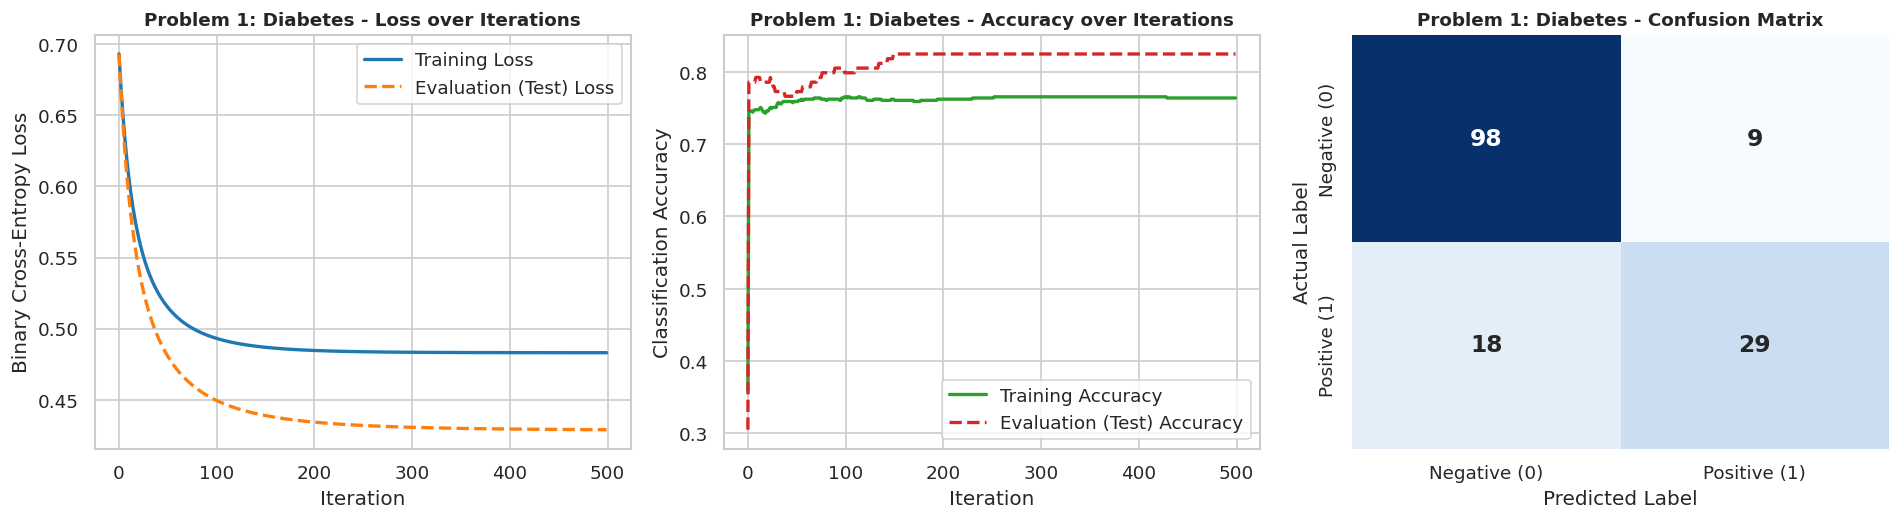

In [3]:

# PROBLEM 1: Diabetes Binary Classifier

diabetes_df = pd.read_csv('diabetes.csv')
print("Diabetes Dataset Shape:", diabetes_df.shape)
display(diabetes_df.head())
display(diabetes_df.describe().T[['count', 'mean', '50%', 'min', 'max', 'std']])

# Separate features (8 inputs) and binary target ('Outcome')
X_diab = diabetes_df.drop(columns=['Outcome']).values
y_diab = diabetes_df['Outcome'].values

# 80% Training (614 samples) and 20% Evaluation/Test (154 samples)
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(
    X_diab, y_diab, test_size=0.20, random_state=0
)

# Standardize features using training set statistics only
scaler_d = StandardScaler()
X_d_train_scaled = scaler_d.fit_transform(X_d_train)
X_d_test_scaled = scaler_d.transform(X_d_test)

# Train Logistic Regression via Gradient Descent
theta_d, tr_l_d, va_l_d, tr_a_d, va_a_d, y_d_pred = train_logistic_regression(
    X_d_train_scaled, y_d_train, X_d_test_scaled, y_d_test,
    lr=0.1, epochs=500, l2_lambda=0.0
)

# Report Metrics and Plot Loss, Accuracy, and Confusion Matrix
p1_metrics = evaluate_and_plot(
    y_d_test, y_d_pred, tr_l_d, va_l_d, tr_a_d, va_a_d,
    class_names=['Negative (0)', 'Positive (1)'],
    title_prefix='Problem 1: Diabetes',
    cmap='Blues',
    save_path='problem1_diabetes_results.png'
)

Cancer Features Shape: (569, 30) | Benign (0): 357, Malignant (1): 212
Unpenalized Weight L2 Norm ||theta||_2: 6.8744

================ Problem 2.1: Cancer (No Penalty) ================
Accuracy  : 0.9561 (95.61%)
Precision : 0.9375 (93.75%)
Recall    : 0.9574 (95.74%)
F1 Score  : 0.9474 (94.74%)
Final Training Loss   : 0.0426
Final Evaluation Loss : 0.1428

Classification Report:
                precision    recall  f1-score   support

   Benign (0)       0.97      0.96      0.96        67
Malignant (1)       0.94      0.96      0.95        47

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114



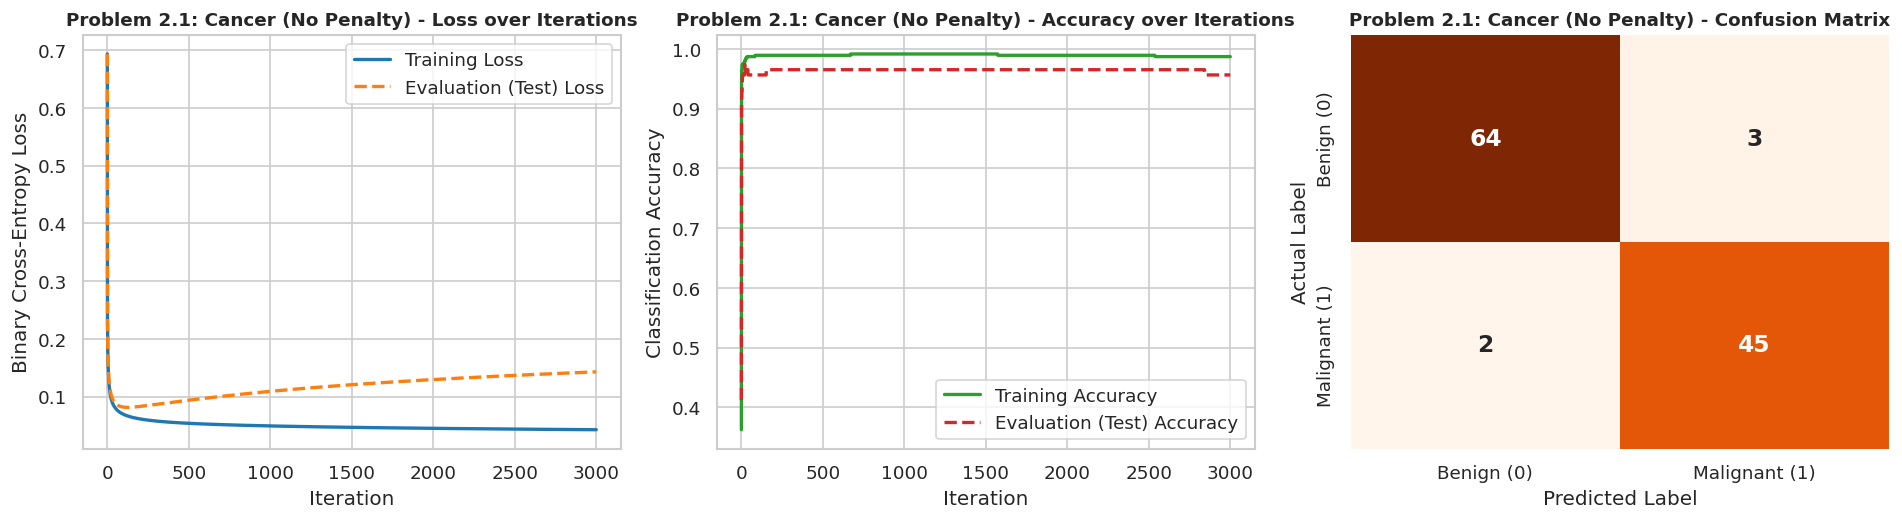

In [4]:

# PROBLEM 2 Cancer Dataset

cancer_df = pd.read_csv('Cancer.csv')

# Drop non-predictive 'id' and empty 'Unnamed: 32' columns
cancer_clean = cancer_df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

# Map target diagnosis: Malignant ('M') -> 1, Benign ('B') -> 0
y_canc = cancer_clean['diagnosis'].map({'M': 1, 'B': 0}).values
X_canc = cancer_clean.drop(columns=['diagnosis']).values

print(f"Cancer Features Shape: {X_canc.shape} | Benign (0): {np.sum(y_canc==0)}, Malignant (1): {np.sum(y_canc==1)}")

# 80% Training (455 samples) and 20% Evaluation/Test (114 samples)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_canc, y_canc, test_size=0.20, random_state=0
)

# Standardize all 30 features
scaler_c = StandardScaler()
X_c_train_scaled = scaler_c.fit_transform(X_c_train)
X_c_test_scaled = scaler_c.transform(X_c_test)

# Train Unpenalized Logistic Regression (l2_lambda = 0.0)
theta_c0, tr_l_c0, va_l_c0, tr_a_c0, va_a_c0, y_c0_pred = train_logistic_regression(
    X_c_train_scaled, y_c_train, X_c_test_scaled, y_c_test,
    lr=0.5, epochs=3000, l2_lambda=0.0
)

print(f"Unpenalized Weight L2 Norm ||theta||_2: {np.linalg.norm(theta_c0[1:]):.4f}\n")

p2_1_metrics = evaluate_and_plot(
    y_c_test, y_c0_pred, tr_l_c0, va_l_c0, tr_a_c0, va_a_c0,
    class_names=['Benign (0)', 'Malignant (1)'],
    title_prefix='Problem 2.1: Cancer (No Penalty)',
    cmap='Oranges',
    save_path='problem2_1_cancer_unpenalized.png'
)

L2-Penalized Weight L2 Norm ||theta||_2: 3.6141

================ Problem 2.2: Cancer (L2 Penalty λ=1.0) ================
Accuracy  : 0.9649 (96.49%)
Precision : 0.9574 (95.74%)
Recall    : 0.9574 (95.74%)
F1 Score  : 0.9574 (95.74%)
Final Training Loss   : 0.0699
Final Evaluation Loss : 0.0924

Classification Report:
                precision    recall  f1-score   support

   Benign (0)       0.97      0.97      0.97        67
Malignant (1)       0.96      0.96      0.96        47

     accuracy                           0.96       114
    macro avg       0.96      0.96      0.96       114
 weighted avg       0.96      0.96      0.96       114



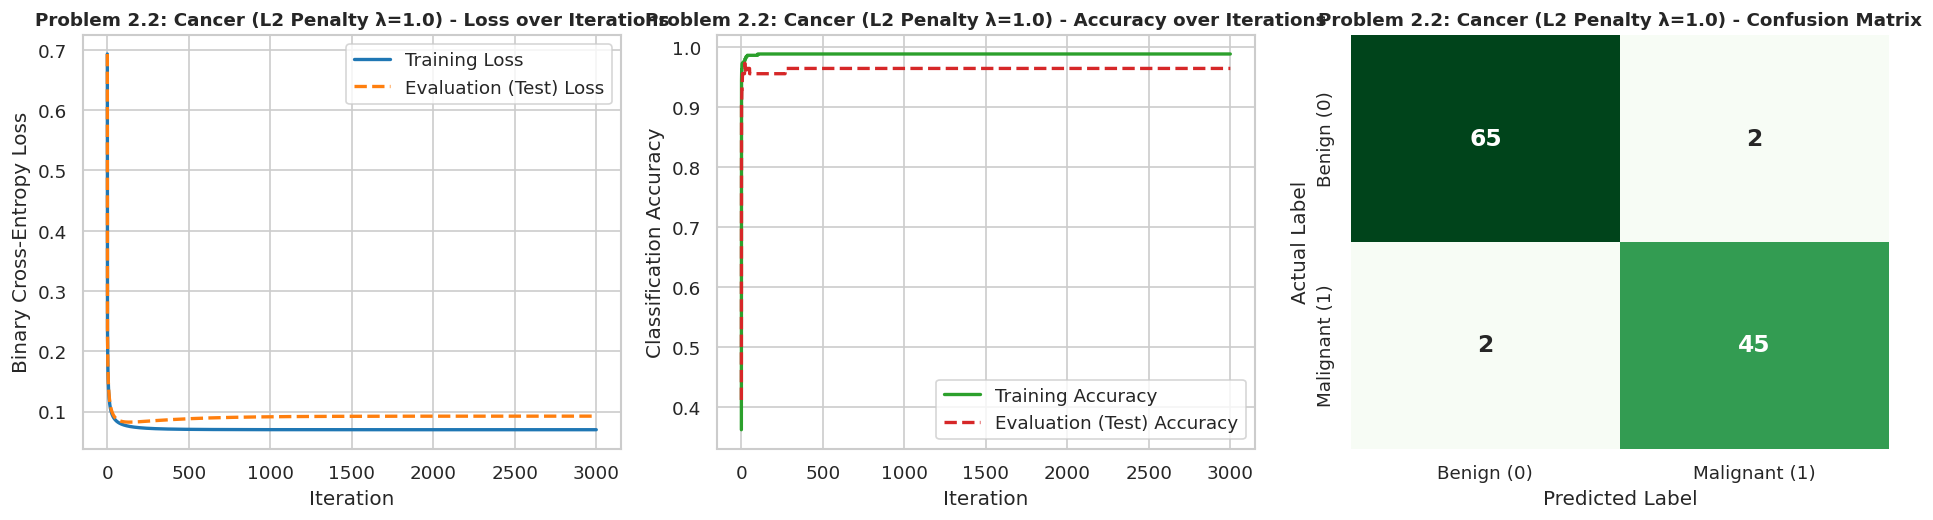

,Model,Accuracy,Precision,Recall,F1,Final Eval Loss,Weight L2 Norm
0,Problem 1: Diabetes (No Penalty),0.8247,0.7632,0.6170,0.6824,0.4289,1.3963
1,Problem 2.1: Cancer (No Penalty),0.9561,0.9375,0.9574,0.9474,0.1428,6.8744
2,Problem 2.2: Cancer (L2 Penalty λ=1.0),0.9649,0.9574,0.9574,0.9574,0.0924,3.6141


In [5]:

# PROBLEM 2  Cancer Dataset  Weight Penalty

# Train L2-Penalized Logistic Regression
theta_c1, tr_l_c1, va_l_c1, tr_a_c1, va_a_c1, y_c1_pred = train_logistic_regression(
    X_c_train_scaled, y_c_train, X_c_test_scaled, y_c_test,
    lr=0.5, epochs=3000, l2_lambda=1.0
)

print(f"L2-Penalized Weight L2 Norm ||theta||_2: {np.linalg.norm(theta_c1[1:]):.4f}\n")

p2_2_metrics = evaluate_and_plot(
    y_c_test, y_c1_pred, tr_l_c1, va_l_c1, tr_a_c1, va_a_c1,
    class_names=['Benign (0)', 'Malignant (1)'],
    title_prefix='Problem 2.2: Cancer (L2 Penalty λ=1.0)',
    cmap='Greens',
    save_path='problem2_2_cancer_penalized.png'
)

# Display Side-by-Side Summary Comparison Table
summary_df = pd.DataFrame([
    {'Model': 'Problem 1: Diabetes (No Penalty)', **p1_metrics,
     'Final Eval Loss': va_l_d[-1], 'Weight L2 Norm': np.linalg.norm(theta_d[1:])},
    {'Model': 'Problem 2.1: Cancer (No Penalty)', **p2_1_metrics,
     'Final Eval Loss': va_l_c0[-1], 'Weight L2 Norm': np.linalg.norm(theta_c0[1:])},
    {'Model': 'Problem 2.2: Cancer (L2 Penalty λ=1.0)', **p2_2_metrics,
     'Final Eval Loss': va_l_c1[-1], 'Weight L2 Norm': np.linalg.norm(theta_c1[1:])}
])
display(summary_df.round(4))